# AirBnB Data Analysis with Python
Exploratory data analysis is a critical first step in any data science project. We will take the opportunity to drill down into a data set containing AirBnB listings with the larger goal of deriving insights and practicing our skills in Python data analytics using some of the most relied-upon libraries.

We'll cover data loading, preprocessing, visualization, and interpretation. This analysis will help us understand pricing patterns, review distributions, and geographical trends in the Airbnb market.

## Step 1: Setting Up the Environment
First, we need to import the necessary libraries:


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

These libraries provide tools for data manipulation (pandas), static visualization (matplotlib and seaborn), and interactive visualization (plotly).

## Step 2: Loading the Data
We'll load our data from a CSV file hosted on Google Drive. We can use this boiler-plate for importing any csv data from a Drive link. The code turns the link into a format that is readable using the pandas `read_csv` method.
```
import requests
from io import StringIO

orig_url="https://drive.google.com/uc?export=download&id="

file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text

csv_raw = StringIO(url)
df = pd.read_csv(csv_raw)
df.head()
```

Run the code block below to import the data from a Google Drive link.

In [ ]:
import requests
from io import StringIO
import pandas as pd

# get the share link from Google Drive
orig_url="https://drive.google.com/file/d/1oQCHkITof93MmFeOSkwVZCuFGmYBEkMA/view?usp=sharing"

file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text

csv_raw = StringIO(url)
df = pd.read_csv(csv_raw)

# examine the first few lines of the data set
df.head()

/tmp/ipython-input-3562587671.py:13: DtypeWarning:

Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75356,-73.98559,Entire home/apt,150,30,48,2019-11-04,0.33,3,334,0,NaN
1,3831,"Whole flr w/private bdrm, bath & kitchen(pls r...",4869,LisaRoxanne,Brooklyn,Bedford-Stuyvesant,40.68494,-73.95765,Entire home/apt,73,1,409,2021-10-22,4.62,1,214,26,NaN
2,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68535,-73.95512,Private room,60,30,50,2019-12-02,0.33,2,365,0,NaN
3,5136,"Spacious Brooklyn Duplex, Patio + Garden",7378,Rebecca,Brooklyn,Sunset Park,40.66265,-73.99454,Entire home/apt,275,5,2,2021-08-08,0.02,1,152,1,NaN
4,5178,Large Furnished Room Near B'way„ÄÄ,8967,Shunichi,Manhattan,Midtown,40.76457,-73.98317,Private room,68,2,514,2021-12-21,3.33,1,198,40,NaN


This code downloads the CSV file and loads it into a pandas DataFrame. This approach allows us to work with data stored in the cloud, which is common in business environments.

## Step 3: Data Preprocessing
Let's examine the data types and check for missing values.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38185 entries, 0 to 38184
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              38185 non-null  int64  
 1   name                            38171 non-null  object 
 2   host_id                         38185 non-null  int64  
 3   host_name                       38138 non-null  object 
 4   neighbourhood_group             38185 non-null  object 
 5   neighbourhood                   38185 non-null  object 
 6   latitude                        38185 non-null  float64
 7   longitude                       38185 non-null  float64
 8   room_type                       38185 non-null  object 
 9   price                           38185 non-null  int64  
 10  minimum_nights                  38185 non-null  int64  
 11  number_of_reviews               38185 non-null  int64  
 12  last_review                     

**Missing Values:** We can see that there are some missing values. There are a few ways to handle this. Because this analysis is focused on data summary and visualization and not predictive modeling, we will not need to deal with missing values at this time. This topic will be addressed in a future case study.

**Data Types:** We can see that we have integers, floats, and objects. Once again, because we are simply working on exploratory tasks in these exercises, we do not need to manage the data types. When we run machine learning models, all data types must be numeric and we will have to make thoughtful decisions about how to represent categorical data numerically.

### 3.1 Feature Engineering
Create a new column called `Occupancy_per_month` using the calculation. Round the final result to the nearest integer.
```
(365-df['availability_365'])/12
```

In [ ]:
df['occupancy_per_month']=round((365 - df['availability_365']) / 12)

## Step 4: Data Aggregation

We'll group our data by neighborhood and room type:


In [ ]:
import seaborn as sns

# Set up the plot style
sns.set_palette("Set3")
sns.set_style("whitegrid")

# Group the data by neighborhood and room type
grouped_data = df.groupby(['neighbourhood_group', 'room_type']).agg({
    'price': 'median',
    'number_of_reviews': 'median'
}).reset_index()

This aggregation calculates the average price and total number of reviews for each combination of neighborhood group and room type.

## Step 5: Visualization
We will explore various graphics to better understand the patterns and relationships in the AirBnB data set.

### 5.1: Bar Charts

We'll create two bar charts to visualize our aggregated data:


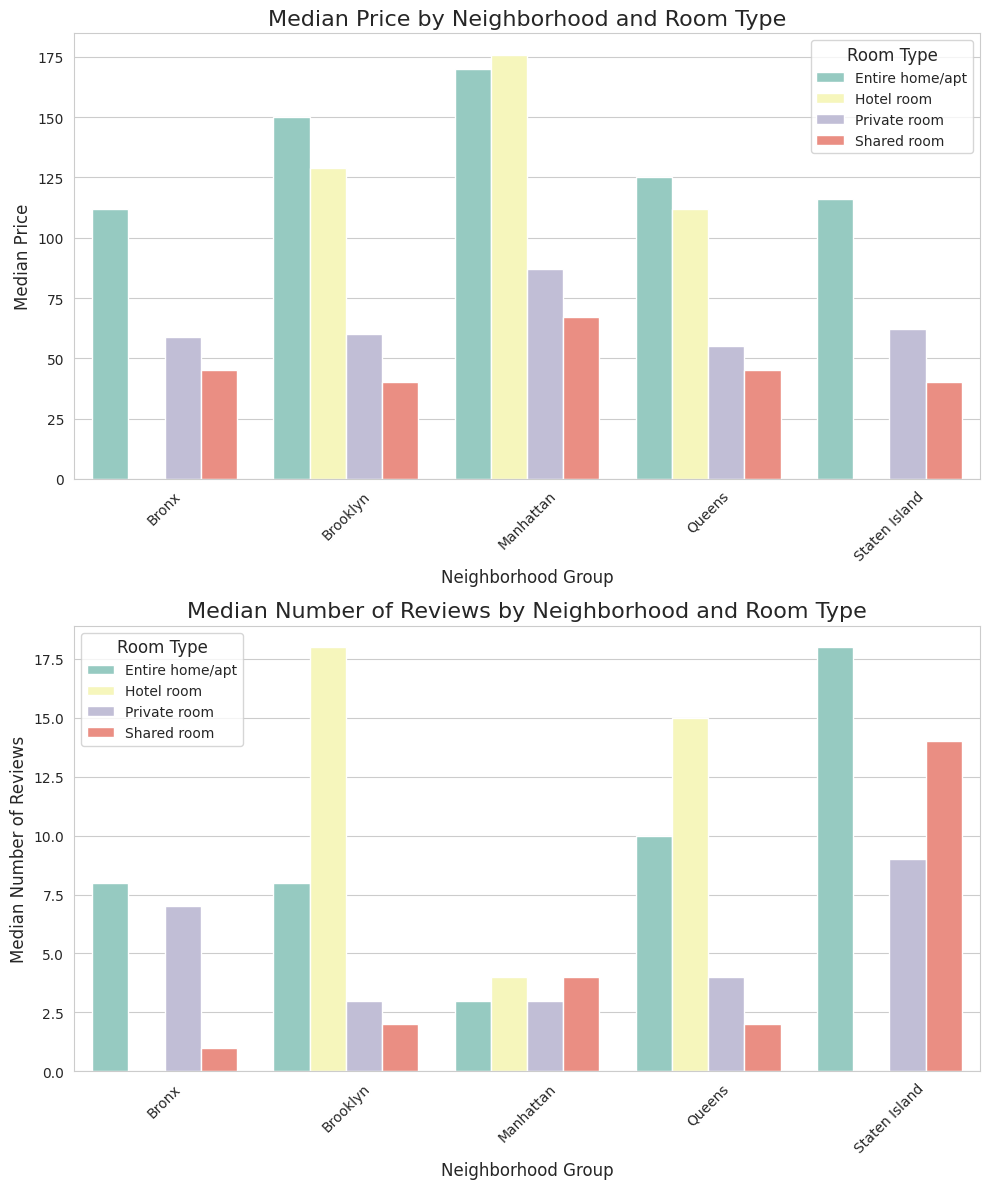

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot style
sns.set_palette("Set3")
sns.set_style("whitegrid")  # Add a Seaborn style if desired

# Create two separate plots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 12))

# Plot for Average Price
sns.barplot(x='neighbourhood_group', y='price', hue='room_type', data=grouped_data, ax=ax1)
ax1.set_title('Median Price by Neighborhood and Room Type', fontsize=16)
ax1.set_xlabel('Neighborhood Group', fontsize=12)
ax1.set_ylabel('Median Price', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Room Type', title_fontsize='12', fontsize='10')

# Plot for Number of Reviews
sns.barplot(x='neighbourhood_group', y='number_of_reviews', hue='room_type', data=grouped_data, ax=ax2)
ax2.set_title('Median Number of Reviews by Neighborhood and Room Type', fontsize=16)
ax2.set_xlabel('Neighborhood Group', fontsize=12)
ax2.set_ylabel('Median Number of Reviews', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Room Type', title_fontsize='12', fontsize='10')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

These charts show the average price and total number of reviews for each neighborhood group, broken down by room type.

1. Price Analysis:
   - Identify which neighborhood groups have the highest and lowest average prices.
    - **Manhattan has highest and Staten has lowest**
   - Describe how prices vary across room types within each neighborhood group.
    - **Entire homes/apartments are the most expensive in every neighborhood group, private rooms are moderately priced, and shared rooms are consistently the cheapest.**
   - Discuss, briefly, any unexpected patterns, such as certain room types being more expensive in specific neighborhoods groups.
    - **In some lower‑priced neighborhoods like Queens and the Bronx, private rooms occasionally approach the price levels of entire homes in other areas, showing that room‑type pricing is not uniform across the city.**

2. Review Analysis:
   - Determine which neighborhood groups and room types receive the most reviews.
    - **Manhattan and Brooklyn receive the most reviews overall, with private rooms showing the highest review counts across room types.**
   - Compare the number of reviews to the average prices. Are more expensive areas receiving more or fewer reviews?
    - **More expensive areas like Manhattan still receive a high number of reviews, suggesting strong demand despite higher prices.**


### 5.2 Visualizing Numerical Data with Histograms and Boxplots
Examining distributions of occupancy rates by room type and neighborhood group.

### Histograms

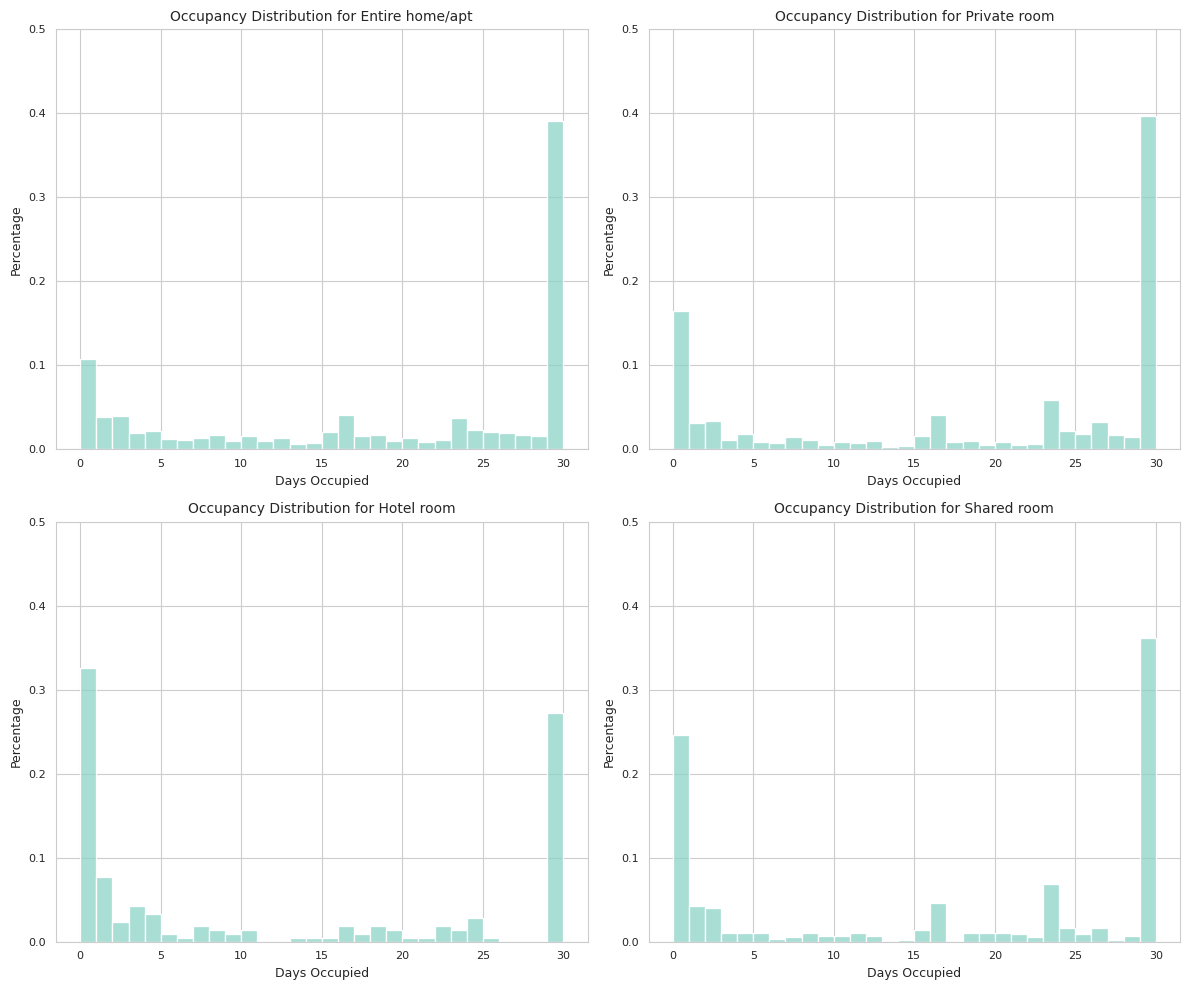

In [ ]:
# Calculate the maximum occupancy for setting y-axis limits
max_occupancy = df['occupancy_per_month'].max()

# Define room types
room_types = df['room_type'].unique()

# Set up the plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the axes array for easier iteration
bin_width = 1  # Define the desired bin width

# Create histograms for each room type
for i, room_type in enumerate(room_types):
    ax = axes[i]
    subset = df[df['room_type'] == room_type]
    sns.histplot(subset['occupancy_per_month'], ax=ax, stat='probability', binwidth=bin_width)
    ax.set_title(f'Occupancy Distribution for {room_type}', fontsize=10)
    ax.set_xlabel('Days Occupied', fontsize=9)
    ax.set_ylabel('Percentage', fontsize=9)
    ax.set_ylim(0, .5) # Set consistent y-axis limits for all plots
    ax.tick_params(axis='both', which='major', labelsize=8) # Adjust tick label size

# Remove any unused subplots
for j in range(len(room_types), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

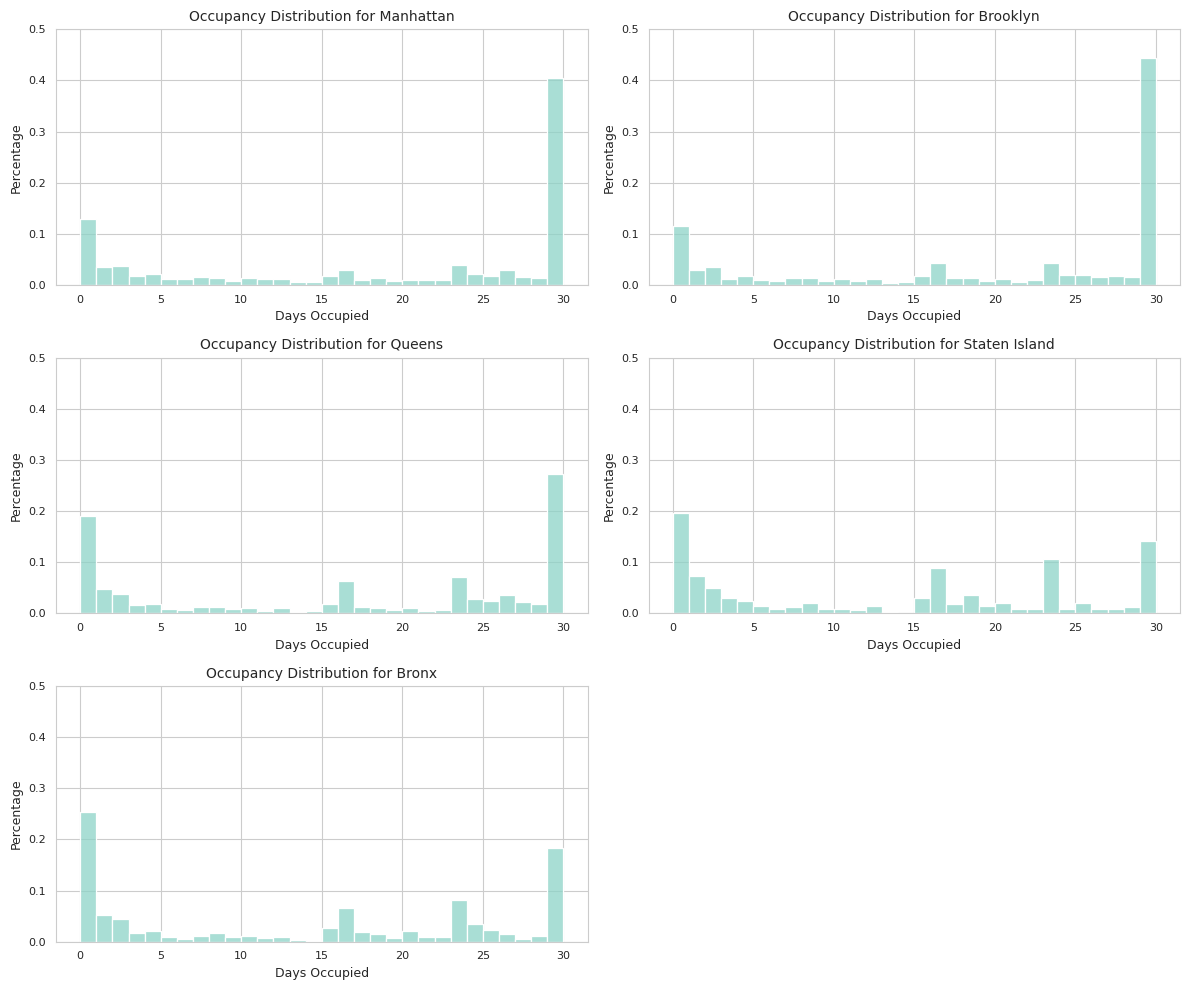

In [ ]:
# Calculate the maximum occupancy for setting y-axis limits
max_occupancy = df['occupancy_per_month'].max()

# Define neighborhood groups
neighborhood_groups = df['neighbourhood_group'].unique()

# Set up the plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten the axes array for easier iteration
bin_width = 1  # Define the desired bin width

# Create histograms for each neighborhood group
for i, neighborhood_group in enumerate(neighborhood_groups):
    ax = axes[i]
    subset = df[df['neighbourhood_group'] == neighborhood_group]
    sns.histplot(subset['occupancy_per_month'], ax=ax, stat='probability', binwidth=bin_width)
    ax.set_title(f'Occupancy Distribution for {neighborhood_group}', fontsize=10)
    ax.set_xlabel('Days Occupied', fontsize=9)
    ax.set_ylabel('Percentage', fontsize=9)
    ax.set_ylim(0, .5)  # Set consistent y-axis limits for all plots
    ax.tick_params(axis='both', which='major', labelsize=8)  # Adjust tick label size

# Remove any unused subplots
for j in range(len(neighborhood_groups), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots

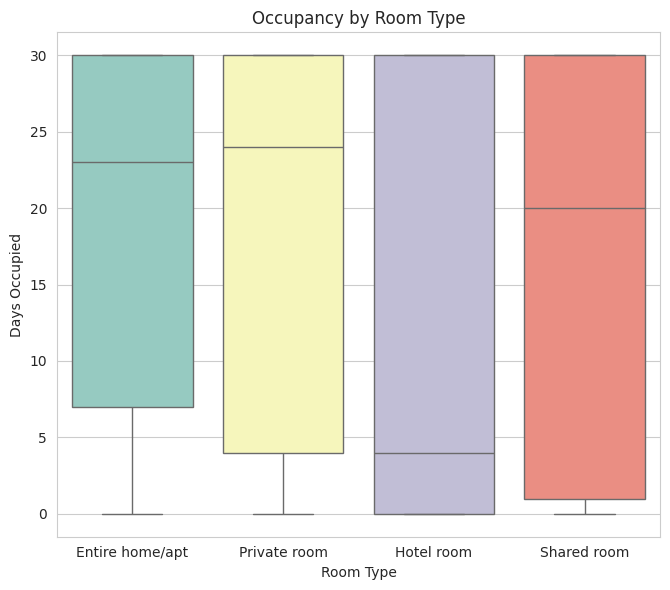

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("Set3")
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='room_type', y='occupancy_per_month', hue='room_type', data=df)
plt.title('Occupancy by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Days Occupied')

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjusts plot area to make room for the legend
plt.show()

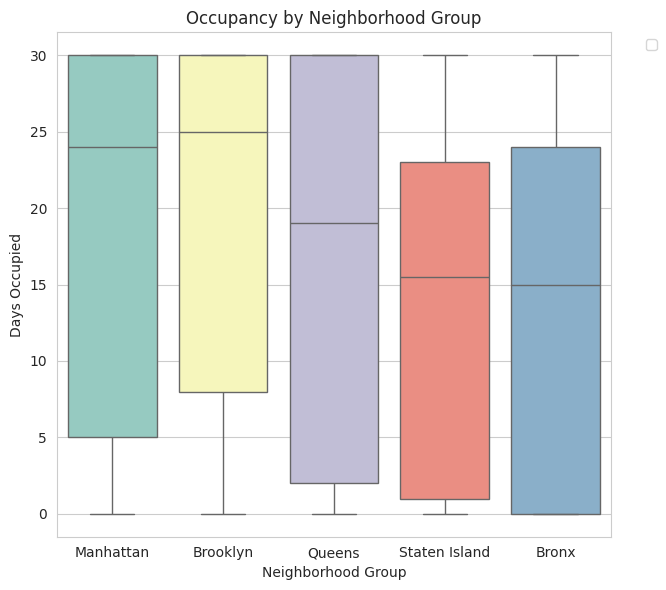

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("Set3")
sns.set_style("whitegrid")

plt.figure(figsize=(8, 6))
sns.boxplot(x='neighbourhood_group', y='occupancy_per_month', hue='neighbourhood_group', data=df)
plt.title('Occupancy by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Days Occupied')

# Ensure legend is added correctly
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjusts plot area to make room for the legend
plt.show()

3. Occupancy Analysis:
    - What insights can histograms provide about the distribution of occupancy rates that boxplots might not?  
     - **Histograms reveal the full shape of the distribution, showing peaks, gaps, skewness, and whether occupancy clusters around certain values.**
    - What advantage do boxplots provide when visualizing occupancy rates by neighborhood?
     - **Boxplots make it easy to compare medians, variability, and outliers across neighborhoods in a compact, side‑by‑side format.**

### 5.3 Examining Relationships with Scatterplots
We can display multiple variables in a single graphic by using a scatterplot to show the relationship between two numerical variables. We will make use of color and size to show additional variables on the same plot.

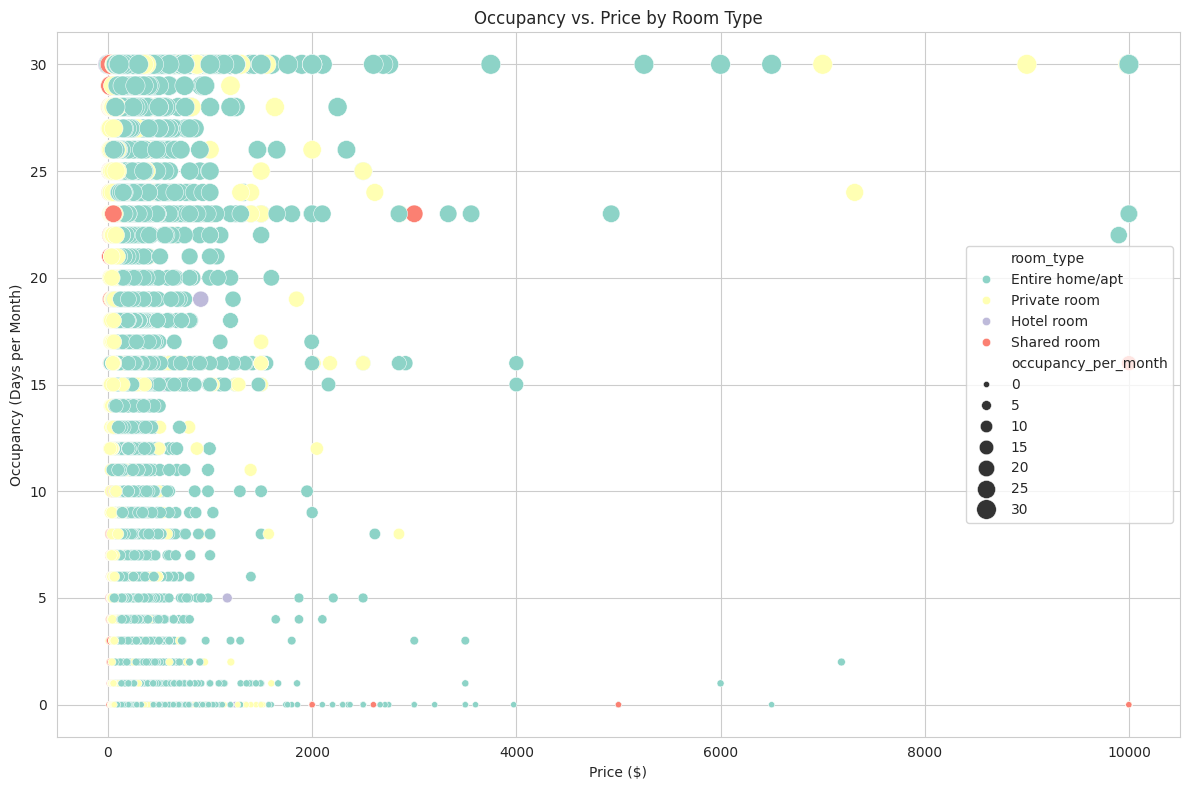

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df, x='price', y='occupancy_per_month', hue='room_type', size='occupancy_per_month', sizes=(20, 200))

plt.xlabel('Price ($)')
plt.ylabel('Occupancy (Days per Month)')
plt.title('Occupancy vs. Price by Room Type')

plt.tight_layout()
plt.show()

4. Examining Relationships with Scatterplots

    - What does the relationship between price and occupancy tell us about the demand for different room types?
        - **Higher‑priced listings tend to show lower occupancy, while moderately priced private rooms maintain stronger demand, indicating guests prefer affordable options across room types.**

### 5.4 Drilling Down
In this section we practice filtering the data frame so that we can take a closer look at the most expensive properties with the highest occupancy rates, excluding those properties that require a full month rental.

In [ ]:
# Filter for properties with over 90% occupancy and price $1000 or more, and minimum nights less than or equal to 29
filtered_df = df[(df['occupancy_per_month'] > (30.41666667 * 0.9)) & (df['price'] >= 1000) & (df['minimum_nights'] <= 29)&(df['neighbourhood_group']=='Manhattan')]

# Display the filtered records in a table
pd.set_option('display.max_rows', None)  # Show all rows
filtered_df[['name', 'neighbourhood_group', 'room_type', 'price','minimum_nights', 'occupancy_per_month']]

,name,neighbourhood_group,room_type,price,minimum_nights,occupancy_per_month
2297,"Luxury 5BR Townhouse, Upper East",Manhattan,Entire home/apt,2249,3,28.0
8119,Gramercy Townhouse- Perfect Work from Home,Manhattan,Entire home/apt,1430,10,30.0
11963,1 Bdrm Apt in Nolita/Little Italy,Manhattan,Entire home/apt,1074,1,30.0
21102,"Shoreham Hotel, Standard Queen",Manhattan,Private room,1000,1,30.0
23733,Luxury Aprtment for Rent in Flatiron,Manhattan,Entire home/apt,1000,3,30.0
24936,NYE 2020 Deluxe NYC Resort by MACY'S & Time Sq...,Manhattan,Private room,1250,4,30.0
27711,Midtown 45 Two-Bedroom Prime location w/rooftop,Manhattan,Entire home/apt,1999,3,30.0
29032,Stunning Downtown Penthouse with 5 BR | 4.5 B,Manhattan,Entire home/apt,1250,14,30.0
33846,New Year in New York Midtown 45 Club Wyndham,Manhattan,Private room,1200,3,29.0
34136,Leave Earth and Sleep on the Surface of Mars!,Manhattan,Entire home/apt,1000,1,30.0


Reset pandas to display a compressed view when showing a data frame.

In [ ]:
pd.reset_option('display.max_rows') # Reset to default

Create a boxplot to show the distribution of prices for the most expensive listings in Manhattan by Room Type.

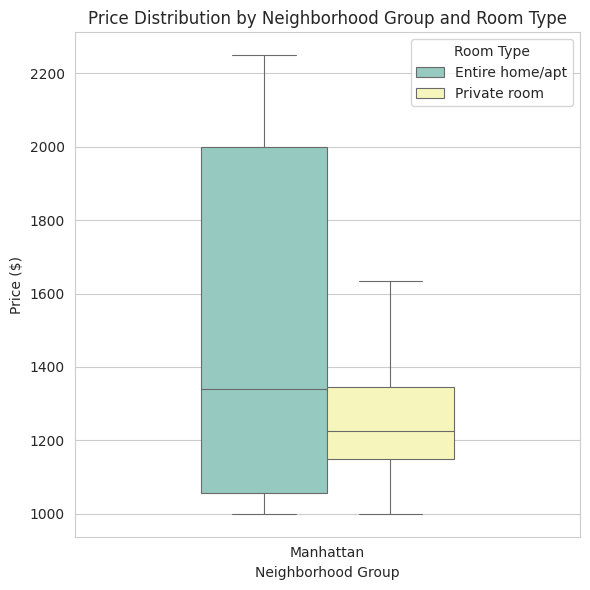

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(6, 6))

# Create a grouped box plot with smaller size and gaps
sns.boxplot(x='neighbourhood_group', y='price', hue='room_type', data=filtered_df, width=0.5, linewidth=0.8) # Adjust width for smaller boxes

# Add titles and labels
plt.title('Price Distribution by Neighborhood Group and Room Type')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price ($)')

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.5) # Adjust wspace for gap between plots


# Show the plot
plt.legend(title='Room Type')
plt.tight_layout()
plt.show()

5. Drilling Down:
    - What business implications arise from focusing on properties with high occupancy and high price?
        - **These listings signal strong, resilient demand, meaning they can justify premium pricing, attract repeat guests, and serve as benchmarks for revenue‑maximizing strategies in similar neighborhoods or room types.**
    - How might excluding listings with minimum nights above 29 days affect the analysis and the insights drawn from it?
        - **Removing long‑stay listings filters out atypical, low‑turnover properties, giving a clearer picture of short‑term rental behavior but potentially overlooking a segment that contributes meaningfully to revenue in certain neighborhoods.**

### 5.5: Geographic Visualization

We'll create an interactive map to visualize the geographic distribution of listings:

In [ ]:
import plotly.express as px

# Create a scatter plot on a map
fig = px.scatter_mapbox(df,
                        lat='latitude',
                        lon='longitude',
                        color='neighbourhood_group',
                        color_discrete_sequence=px.colors.qualitative.Pastel, # Use a discrete color sequence
                        size='price',
                        hover_name='name',
                        zoom=10,
                        opacity=0.5,
                        category_orders={"neighbourhood_group": df['neighbourhood_group'].unique()}) # Correct color mapping

fig.update_layout(mapbox_style="carto-positron", height=800) # Increased height
fig.show()

6. Geographic Analysis:
   - Briefly describe the distribution of listings across the city.
       - **Listings are heavily concentrated in Manhattan and Brooklyn, with additional clusters in Queens and smaller pockets in the Bronx and Staten Island. The density patterns reflect where short‑term rental activity is most active across the city.
**
   - Identify and briefly discuss any geographic patterns in pricing or neighborhood groupings.
       - **Higher‑priced listings cluster in central Manhattan and along waterfront areas, while more affordable listings appear in outer boroughs like Queens, the Bronx, and Staten Island. Distinct neighborhood groupings emerge visually, showing clear geographic segmentation in both price and listing density.**


## General Questions

7. Business Insights:
   - For hosts: Identify potentially underpriced or overpriced areas based on location and occupancy.
       - **High‑occupancy, high‑price clusters in Manhattan and parts of Brooklyn suggest room for further price optimization, while low‑occupancy pockets in outer boroughs may indicate overpriced listings that could benefit from strategic price adjustments.**
   - For guests: Find neighborhoods that offer good value (lower prices but still well-attended).
       - **Queens and parts of Brooklyn offer strong value, with moderate prices and healthy occupancy levels, making them attractive alternatives to Manhattan for budget‑conscious travelers.**
   - For Airbnb: Spot areas that might be underserved or oversaturated with listings.
       - **Manhattan and central Brooklyn appear saturated with listings, while areas like Staten Island and parts of the Bronx show sparse coverage, signaling potential opportunities for targeted host recruitment or localized marketing.**


8. Further Questions (do a little outside research):
   - What factors might explain the price differences between neighborhoods?
       - **Prices vary due to proximity to major attractions, transit access, neighborhood safety, local amenities, historical prestige (e.g., Manhattan), and zoning or housing‑supply constraints that limit available short‑term rentals.**
   - How might seasonality affect these patterns?
       - **Demand spikes during peak tourism seasons (summer, holidays, major events), raising prices and occupancy in central neighborhoods, while off‑season months lead to softer demand and more competitive pricing across all boroughs.**
   - Are there correlations between price, number of reviews, and location that could inform business strategies?
       - **Higher‑priced listings in prime areas often accumulate more reviews due to steady demand, while lower‑priced outer‑borough listings may rely on competitive pricing to drive visibility; identifying these correlations helps optimize pricing, marketing, and host investment decisions.**


Optional Dashboard

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import requests
from io import StringIO
from google.colab import data_table

# --- Plotly charts with explicit color settings ---

# 3. Bar Chart of Average Price
print("Average Price by Neighborhood and Room Type")
fig_bar = px.bar(
    grouped_data,
    x='neighbourhood_group',
    y='price',
    color='room_type',  # Color by room type
    barmode='group',
    title='Average Price by Neighborhood and Room Type',
    color_discrete_sequence=px.colors.qualitative.Set3 # Set the color palette here
)
fig_bar.update_layout(width=800, height=400)
fig_bar.show()

# 4. Scatter Plot of Price vs. Occupancy
print("Price vs. Occupancy Analysis")
fig_scatter = px.scatter(
    df,
    x='price',
    y='occupancy_per_month',
    color='room_type', # Color by room type
    size='occupancy_per_month',
    title='Price vs. Occupancy by Room Type',
    labels={'occupancy_per_month': 'Occupancy (Days per Month)', 'price': 'Price ($)'},
    color_discrete_sequence=px.colors.qualitative.Set3 # Set the color palette here
)
fig_scatter.update_layout(width=800, height=500)
fig_scatter.show()

# Interactive Map (no color palette needed, as color is already set by neighborhood_group)
print("Interactive Map of Listings (Geographic Distribution)")
if 'latitude' in df.columns and 'longitude' in df.columns:
    fig_map = px.scatter_mapbox(
        df,
        lat="latitude",
        lon="longitude",
        color="neighbourhood_group",
        size="price",
        hover_name="name",
        zoom=10,
        color_discrete_sequence=px.colors.qualitative.Set3
    )
    fig_map.update_layout(mapbox_style="carto-positron", width=800, height=600)
    fig_map.show()
else:
    print("Geographic data not available for mapping.")


Average Price by Neighborhood and Room Type


Price vs. Occupancy Analysis


Interactive Map of Listings (Geographic Distribution)
